## PanNuke Tissue Classification — Data Exploration

### Objective

Explore the PanNuke dataset structure, tissue-label distribution, and image characteristics before building the classification pipeline.

In [2]:
from pathlib import Path

import numpy as np

DATA_DIR = Path.home() / "datasets" / "PanNuke" / "fold_1"

IMAGE_PATH = DATA_DIR / "images" / "fold1" / "images.npy"
TYPE_PATH = DATA_DIR / "images" / "fold1" / "types.npy"
MASK_PATH = DATA_DIR / "masks" / "fold1" / "masks.npy"

print(IMAGE_PATH)
print(TYPE_PATH)
print(MASK_PATH)

/home/ea/datasets/PanNuke/fold_1/images/fold1/images.npy
/home/ea/datasets/PanNuke/fold_1/images/fold1/types.npy
/home/ea/datasets/PanNuke/fold_1/masks/fold1/masks.npy


In [3]:
images = np.load(IMAGE_PATH, mmap_mode="r")
types = np.load(TYPE_PATH)

print("Imagaes shape:", images.shape)
print("Images dtype:", images.dtype)

print("Types shape:", types.shape)
print("Types dtype:", types.dtype)

Imagaes shape: (2656, 256, 256, 3)
Images dtype: float64
Types shape: (2656,)
Types dtype: <U13


In [4]:
print("Number of images:", len(images))
print("Number of labels:", len(types))
print("One-to-one match:", len(images) == len(types))

Number of images: 2656
Number of labels: 2656
One-to-one match: True


### Tissue Class Distribution

Examine the number of image patches available for each tissue type and assess class imbalance.

In [5]:
classes, counts = np.unique(types, return_counts=True)

print("Number of classes:", len(classes))
print("Total samples:", counts.sum())

for tissue, count in zip(classes, counts):
    print(f"Tissue: {tissue}, Count: {count}")

Number of classes: 19
Total samples: 2656
Tissue: Adrenal_gland, Count: 134
Tissue: Bile-duct, Count: 159
Tissue: Bladder, Count: 21
Tissue: Breast, Count: 827
Tissue: Cervix, Count: 155
Tissue: Colon, Count: 478
Tissue: Esophagus, Count: 155
Tissue: HeadNeck, Count: 70
Tissue: Kidney, Count: 37
Tissue: Liver, Count: 65
Tissue: Lung, Count: 80
Tissue: Ovarian, Count: 54
Tissue: Pancreatic, Count: 78
Tissue: Prostate, Count: 77
Tissue: Skin, Count: 59
Tissue: Stomach, Count: 50
Tissue: Testis, Count: 60
Tissue: Thyroid, Count: 80
Tissue: Uterus, Count: 17


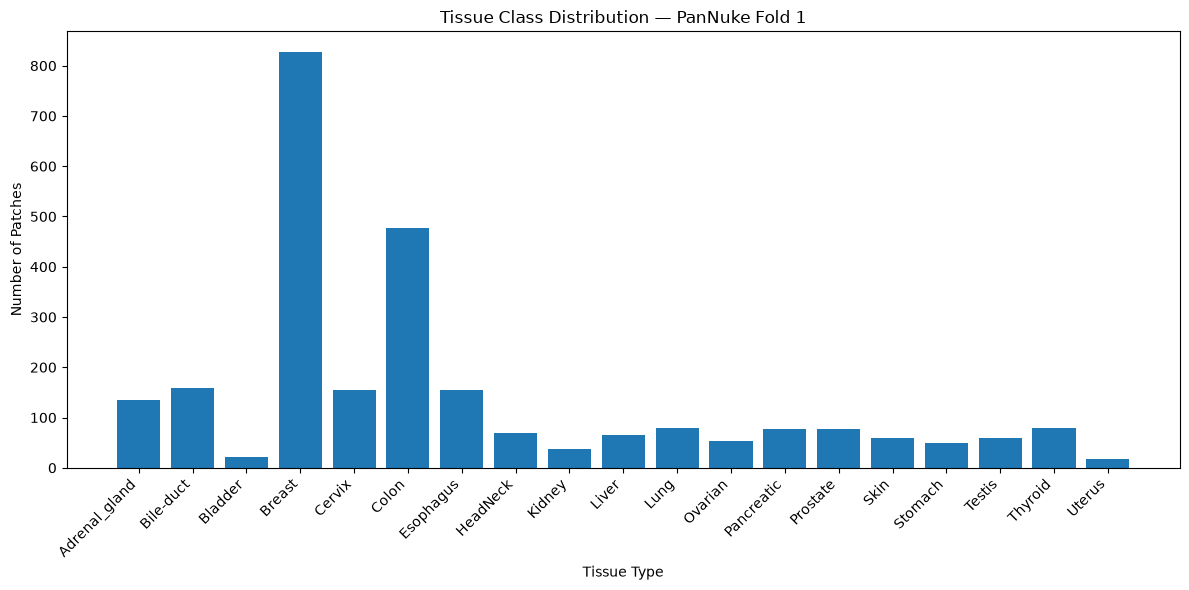

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(classes, counts)

ax.set_title("Tissue Class Distribution — PanNuke Fold 1")
ax.set_xlabel("Tissue Type")
ax.set_ylabel("Number of Patches")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Sample Images by Tissue Type

Visualize representative H&E patches from different tissue classes to inspect morphological and staining variability.

In [7]:
 tissue = "Breast"

 indices = np.where(types == tissue)[0]

 print("Number of Breast patches:", len(indices))
 print("First 10 indices:", indices[:10])

Number of Breast patches: 827
First 10 indices: [0 1 2 3 4 5 6 7 8 9]


##### `imshow()` RGB Image Dtype and Expected Range

| Dtype | Expected RGB Range |
|---|---|
| `uint8` | 0 ~ 255 |
| `float32` / `float64` | 0.0 ~ 1.0 |

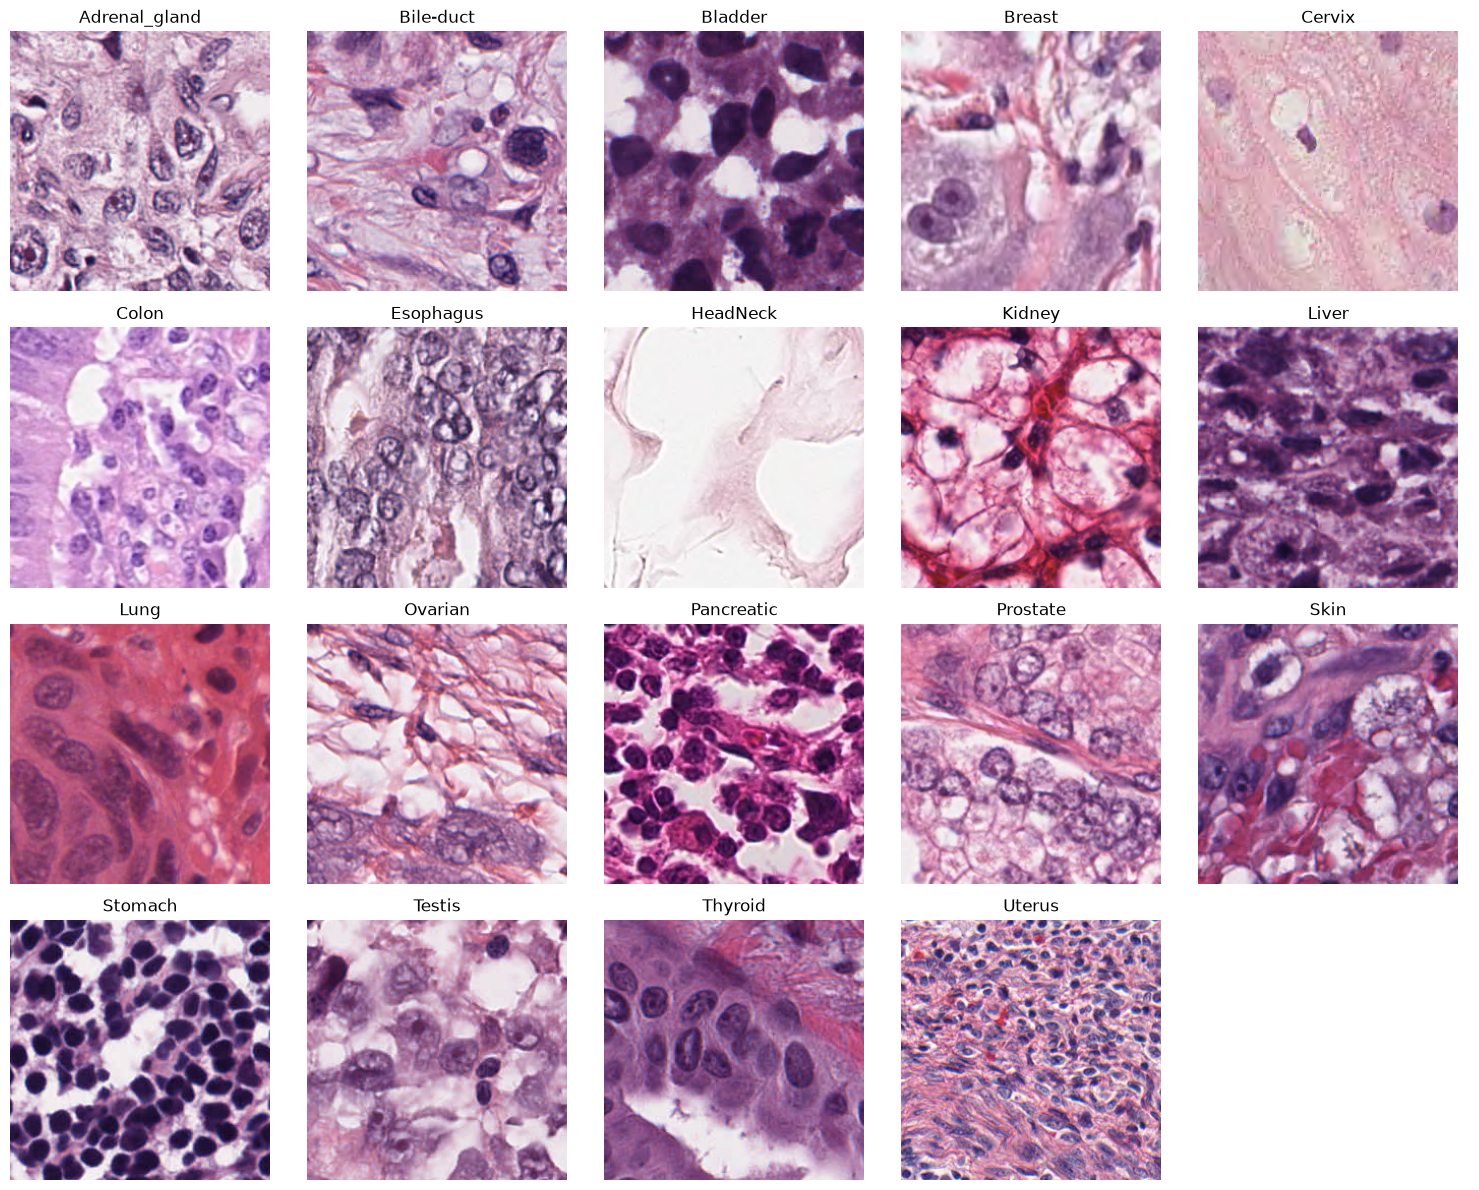

In [8]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

axes = axes.flatten()

for ax, tissue in zip(axes, classes):
    indices = np.where(types == tissue)[0]
    image = images[indices[0]]
    
    
    ax.imshow(image.astype(np.uint8))
    ax.set_title(tissue)
    ax.axis("off")

for ax in axes[len(classes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### Image Characteristics

Inspect the pixel-value range and basic image statistics before defining the preprocessing pipeline.

In [ ]:
# sample_images = images[:100] # 100 breast tissue images
rng = np.random.default_rng(seed=42)

sample_indices = rng.choice(len(images), size=100, replace=False)
sample_images = images[sample_indices]

sample_types = types[sample_indices]

sample_classes, sample_counts = np.unique(sample_types, return_counts=True)

print("Sampled classes:", len(sample_classes))

for tissue, count in zip(sample_classes, sample_counts):
    print(f"Tissue: {tissue}, Count: {count}")

print(sample_indices[:10])
print(sample_images.shape)

print("Shape:", sample_images.shape)
print("Dtype:", sample_images.dtype)
print("Min:", sample_images.min())
print("Max:", sample_images.max())
print("Mean:", sample_images.mean())
print("Std:", sample_images.std())

channel_mean = sample_images.mean(axis=(0, 1, 2)) # remove 0, 1, 2 axis remain only the channel axis (3rd axis) for RGB channels
channel_std = sample_images.std(axis=(0, 1, 2))

print("RGB mean", channel_mean)
print("RGB std", channel_std)

Sampled classes: 18
Tissue: Adrenal_gland, Count: 2
Tissue: Bile-duct, Count: 2
Tissue: Bladder, Count: 3
Tissue: Breast, Count: 24
Tissue: Cervix, Count: 12
Tissue: Colon, Count: 19
Tissue: Esophagus, Count: 5
Tissue: HeadNeck, Count: 4
Tissue: Kidney, Count: 2
Tissue: Liver, Count: 5
Tissue: Lung, Count: 3
Tissue: Ovarian, Count: 2
Tissue: Pancreatic, Count: 3
Tissue: Prostate, Count: 5
Tissue: Skin, Count: 1
Tissue: Stomach, Count: 2
Tissue: Testis, Count: 4
Tissue: Thyroid, Count: 2
[1153 2479 2635 1218 1165 2028  403  854  429 1844]
(100, 256, 256, 3)
Shape: (100, 256, 256, 3)
Dtype: float64
Min: 0.0
Max: 255.0
Mean: 169.54240030924478
Std: 55.733718384967666
RGB mean [188.76384079 142.51991394 177.3434462 ]
RGB std [49.51040905 59.10574874 47.04717947]


: 

Observation

A ramdom sample of 100 patches covered 18 of 19 tissue classes, but the sampled distribution remained imbalanced.  

This reflects the class imbalance present in the origin Fold 1 dataset and motivates the use of stratified sampling when constructing training and validation splits.